In [5]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [6]:
ibge_df = pd.read_csv('../../../IBGE/municipios_regioes.csv')

years = ['2019', '2020', '2021', '2022', '2023', '2024', '2025']

all_years_joined = []

for year in years:
    file_path = f'{year}.xlsx'
    if os.path.exists(file_path):
        atividade_df = pd.read_excel(file_path, decimal=',', thousands='.')

        joined_df = pd.merge(atividade_df, ibge_df, left_on='Ibge', right_on='codigo_municipio_ibge_novo', how='outer')
        joined_df['ano'] = year

        all_years_joined.append(joined_df)
if all_years_joined:
    combined_all_years = pd.concat(all_years_joined, ignore_index=True)
    combined_all_years.head()


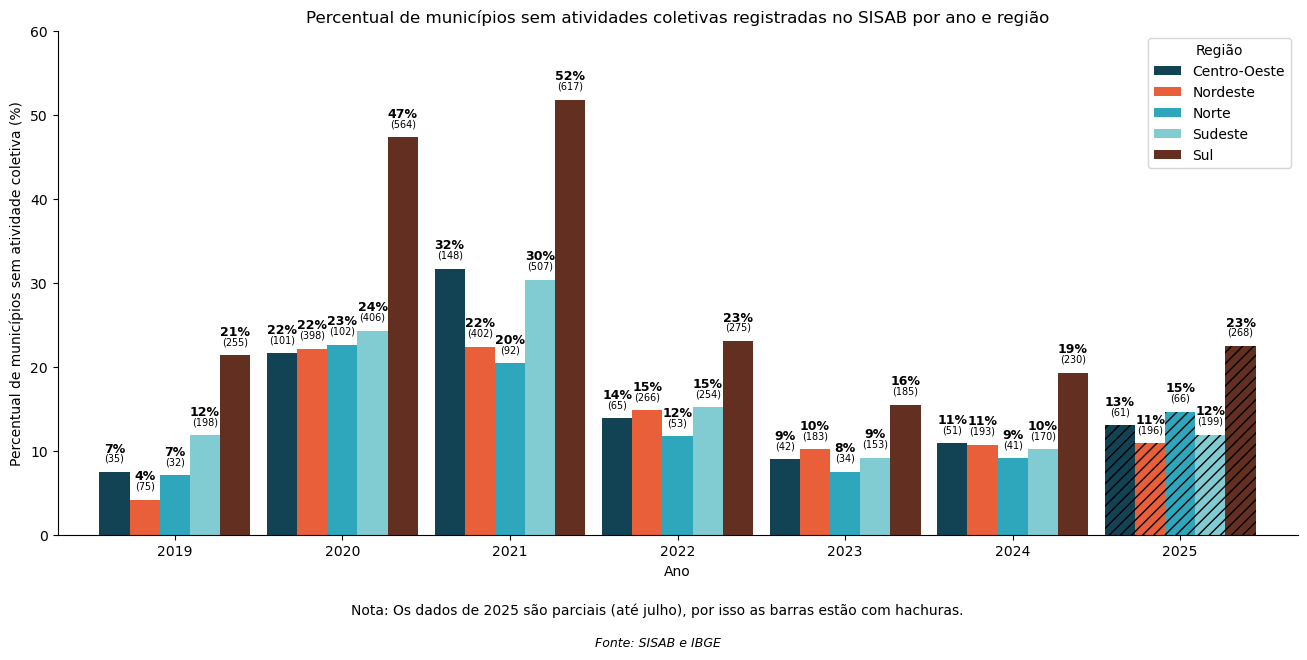

In [7]:
total_por_regiao = combined_all_years.groupby('regiao')['codigo_municipio_ibge_novo'].nunique().reset_index(name='total_municipios')

sem_atividade = combined_all_years[combined_all_years['Uf'].isna()]

contagem = sem_atividade.groupby(['ano', 'regiao']).size().reset_index(name='count_sem')

contagem = contagem.merge(total_por_regiao, on='regiao')

contagem['percentual'] = (contagem['count_sem'] / contagem['total_municipios']) * 100

pivot_df = contagem.pivot(index='ano', columns='regiao', values='percentual').fillna(0)

cat_colors = ["#114354", "#E95F3A", "#2EA6BC", "#81CBD3", "#632F21"]
regions = pivot_df.columns.tolist()
color_dict = dict(zip(regions, cat_colors[:len(regions)]))

fig, ax = plt.subplots(figsize=(16, 8))
bars = pivot_df.plot(kind='bar', stacked=False, ax=ax, color=[color_dict[col] for col in pivot_df.columns], width=0.9)

# Remove side borders
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

for container in ax.containers:
    for j, bar in enumerate(container):
        if j == 6:  # 2025
            bar.set_hatch('///')

for i, (ano, row) in enumerate(pivot_df.iterrows()):
    for j, regiao in enumerate(pivot_df.columns):
        value = row[regiao]
        count = contagem[(contagem['ano'] == ano) & (contagem['regiao'] == regiao)]['count_sem'].values[0]
        bar_width = 0.9 / len(pivot_df.columns)
        x_pos = i + (j - (len(pivot_df.columns) - 1) / 2) * bar_width
        ax.text(x_pos, value + 2, f"{round(value)}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.text(x_pos, value + 1, f"({count})", ha='center', va='bottom', fontsize=7)

plt.title('Percentual de municípios sem atividades coletivas registradas no SISAB por ano e região')
plt.xlabel('Ano')
plt.ylabel('Percentual de municípios sem atividade coletiva (%)')
plt.ylim(bottom=0, top=60)
plt.legend(title='Região')
plt.xticks(rotation=0)
plt.margins(x=0)
plt.subplots_adjust(bottom=0.25)

plt.figtext(0.5, 0.15, 'Nota: Os dados de 2025 são parciais (até julho), por isso as barras estão com hachuras.',
            ha='center', fontsize=10)

plt.figtext(0.5, 0.11, 'Fonte: SISAB e IBGE',
            ha='center', fontsize=9, style='italic')

plt.show()